# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import glob
import sys
from os import listdir
from collections import namedtuple

In [8]:
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [5]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [6]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

In [ ]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [40]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [41]:
bin_info

,min_x,total_x,size_x,max_x,nbins_x,min_y,total_y,size_y,max_y,nbins_y,...,total_z,size_z,max_z,nbins_z,detector_db,binning,Rmax,loss_th,ener_th,max_dis
0,-490.4,972.65,15.55,497.8,64,-487.7,972.65,15.55,500.5,64,...,1300,10,1300,130,next100,sipm,500,0.25,None,1.732051


In [19]:
de = data.groupby('dataset_id')

In [36]:
de.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6804941,10777,-1,12,24,22,0.000193,-1,0.199058,1
6804942,10777,-1,12,25,22,0.000187,-1,0.192026,1
6804943,10777,-1,13,24,22,0.000191,-1,0.143146,1
6804944,10777,-1,14,16,22,0.000236,-1,0.090113,0


In [31]:
de_group = de.get_group(0)

In [34]:
de_group

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
606,0,-1,41,49,87,0.000200,-1,0.121570,1
607,0,-1,41,50,87,0.000440,-1,0.088611,0
608,0,-1,42,46,86,0.000327,-1,0.059792,0
609,0,-1,42,48,86,0.000354,-1,0.103684,0


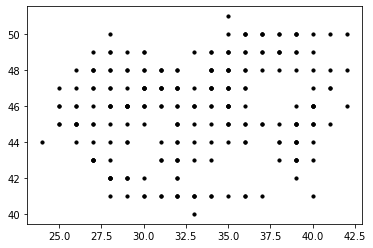

In [ ]:
sel = de_group.decopred == 1
plt.scatter(de_group[sel].xbin, de_group[sel].ybin, s=10)


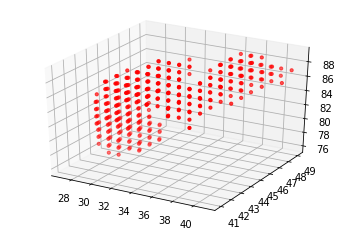

In [56]:
%matplotlib inline
#%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x, y, z = de_group.xbin, de_group.ybin, de_group.zbin
ene = 1000.*de_group.energy
#ax.scatter(x, y, z)
ax.scatter(x[sel], y[sel], z[sel], 
              c='r', s=10)  

In [69]:
de_group.decopred

0      0
1      0
2      0
3      0
4      0
      ..
606    1
607    0
608    0
609    0
610    0
Name: decopred, Length: 611, dtype: int64

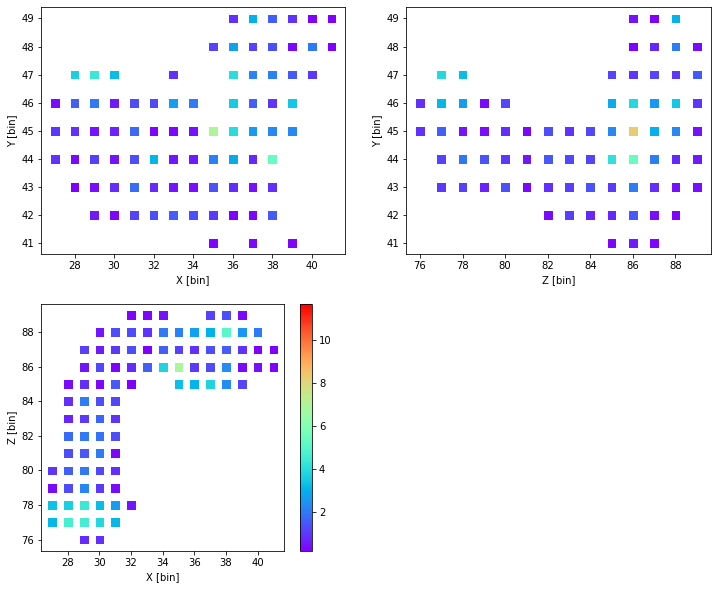

In [70]:
cv = pltext.canvas(4, 2)
sel = de_group.decopred >= 1
cv(1);
plt.scatter(x[sel], y[sel], s=60, marker = 's', c = ene[sel] ); plt.xlabel('X [bin]'); plt.ylabel('Y [bin]');
cv(2); 
plt.scatter(z[sel], y[sel], s=60, marker = 's', c = ene[sel]); plt.xlabel('Z [bin]'); plt.ylabel('Y [bin]');
cv(3);
plt.scatter(x[sel], z[sel], s=60, marker = 's', c = ene[sel]); plt.xlabel('X [bin]'); plt.ylabel('Z [bin]');
plt.colorbar();

